#  🐍📊 NOTEBOOK DE TIMEO 🐍📊

## === GUIDE des fonctions du module local datalake === 

from DATALAKE.data import *

**data = data_download_gmd("country")** -> Telechargement des données liés à un pays via global_macro_dataset (BD publique)
**data = data_download_fred("indicator"** : str, "start" : str , "end" : str) -> Telechargement d'un indicateur via la FRED (BD publique)

**data_storing(data : dataframe, "nom_fichier" : str)** -> Range un dataframe "data" dans le DATALAKE en parquet, que vous venez de télécharger d'internet 

**data = import_parquet("file_name" : str)** -> importe un dataframe du DATALAKE dans votre file cible (notebook ou .py)

**which_parquet()** -> Vous renvoie une liste de l'ensemble des parquets dispo dans le DATALAKE

## === Pour importer les fonctions du fichier "outils_eda", si vous en avez besoin lors de votre analyse ===

import sys
import os

sys.path.append("../dorian_code") -> permet à Python d'aller lire les fichiers présent dans le dossier "dorian_code"

from outils_eda import * -> importe le fichier "outils_eda" dont ces fonctions que vous pouvez utiliser lors de l'analyse !

In [253]:
from DATALAKE.data import *

# **⛓️ Recherches sur l'utilisation du Regime Switching Model de Markov ⛓️** 

## **<span style="color:red">I.     Principe**
Le modele à changement de regime de Markov permet de différencier l'effet d'une variables sur une autre en fonction d'états cachés nommés régimes étant endogène et donc non déterministe. Il apport une solution à nos modèles linéaires à travers la possibilité de modéliser la probabilité de passage entre les différents régimes traversés par les données.

Ce modèle permet d'aller au dela des modèles de changement structurels et permet surtout de mettre en avant la corrélation entre différentes variables dont l'effet évolue en fonction du temps. 


## **<span style="color:red">II.     Problème de notre étude lié directement aux régimes exogenes et discussion de la solution apportée par les chaines de Markov**
Dans les modèles précédents nous regressions de manière directe les rate sur nos différentes variables d'intèret en partant du principe que les threshold exogènes définis par le passage entre les différentes politiques monétaires, sont les réelles jonctions de l'effet observé en fonction des 3 régimes.

Empirquement, ceci peut il poser problème ? Oui. Admettons que les régimes que nous avons prédits comme éxogène et définie par les dates de passages entre les différentes politiques monétaires, nous ometterions par exemple que l'effet des chocs de politique monétaires change non pas uniquement en fonction des threshold donnés mais sont lagged de 5 ans pour le passage gold standard / bretton wood et seulement 2 ans pour le passage entre bretton woods et floating rate, nous sur(/sous)etimerions donc le beta propre aux différents régimes. Par exemple si l'effet des chocs de taux est supérieur durant la période bretton woods, si nous incluons dans l'estimation du beta de la période gold standard les 5 périodes lagged de passage au bretton woods, nous surestimerions le beta propre à la période du gold standard. 

Nous modélisons donc un modèle de passage de régimes endogène au sein de cette troisième partie pour contrôler pour ce risque de BVO propre aux trehsold exogenes. 

## **<span style="color:red">III.   Détail des limites des précédentes méthodes éxpérimentales** 
Pour justifier cette modélisation, mettons en avant les limites de chacune des précédentes méthodes éxperimentales solutionnés par le modèle  de Régime switching Markovien.

#### **<span style="color:green">Dummies regression : Au sein de cette partie nous partons du principe que les périodes des threshold correspondent aux annonces de transition des politiques monétaires.**

1. **Éxogénéité stricte des régimes et passage non dyamique** : si les passages entre les différents régimes sont lagged ou parfois causés par des chocs éxogènes (exemple : passage à bretton wood suite à la 1ere GM car le gold standard ne permettait pas de remonter les taux ), notre modèle peut omettre ce passage et donc perdre en significativité.

_*Markov*_ : Le passage entre les régimes devient endogène ce qui capte par exemple l'effet d'anticipation des périodes. 

2. **Effet constant dans le temps** : Au sein de ce modèle nous partons du principe que l'impact des taux sur les variables d'interets sous un régime donnée ne varie pas à l'intérieur du régime. Ceci peut être problématique car nous pouvons sur/sous éstimer ce même effet par exemple à cause d'une période outlier au sein du régime. Prenons par exemple la période floating rate, donc le beta des taux peut être dévalué à cause des données liés à la crise des subprime de 2008, la crise du COVID de 2021 ou encore homologuement la grande répression de 1930 pour la période Bretton Wood.

_*Markov*_ : Permet de capturer des changements de beta progressifs en fonction du temps et donc au sein de chaque régime, afin de contrôler pour ces "outliers effect" par exemple.

3. **Interactions inter-temporelle entre inflation, PIB et taux de changes** : Au sein de cette méthode de modélisation nous ne prenons pas en compte les chocs inter variables d'intérêts au sein de chaque régimes, potentiellement une source importante de variation que nous pourrions utiliser de 2 manières principales : 

- Cela nous permettrait de modéliser l'éfficacité d'un régime de politique monétaire donné en minimisant la variances entre les différentes variables, signe de stabilisation de l'économie.

- D'un autre sens, ce type de variation nous permettrait à contrario de mettre en avant que le cout associé à un régime donné n'est pas forcément du à l'innefficacité des taux d'interet pour stabiliser l'économie, mais aux variations trop élevés entre les variables du modèles au sein de ce régime. 

_*Markov*_ : Les effets éstimés par le MRS sont dynamique et donc peuvent prendre en compte comme au sein d'un modèle de Time Series comme VAR/SVAR, les interactions dynamiques entre les variables d'intérêts

#### **<span style="color:green">VAR / SVAR : Nous modélisons ici un modèle dynamique de variables (PIB, TI, inflation, taux changes) permettant de capturer les changements progressifs de l'effet des taux sur les variables d'intérêts, solutionnant en partie le points 1. et 3. précédents. Il part néanmoins de l'hypothèse que les régimes sont éxogènes et fixes.**

1. **Éxogénéité stricte des régimes** : Comme précédemment nous éstimons les transitions de manière éxogène. 

_*Markov*_ : Le passage entre les régimes devient endogène et stochastique ce qui capte par exemple l'effet d'anticipation des périodes. 

2. **Effet constant dans le temps** : Également comme précédement, les coefficients ne sont pas variables en fonction du temps. 

_*Markov*_ : Le passage entre les régimes devient endogène ce qui capte par exemple l'effet d'anticipation des périodes


#### **<span style="color:green"> Détails des atouts du modèle de régime Switching de Markov (MRS)**

1.	Les transitions sont endogènes : pas besoin d’annoncer comme fixe les changements de régime.

2.	Paramètres dynamiques par régime : chaque régime peut avoir ses propres coefficients pour le taux d’intérêt, inflation, PIB, etc.

3.	Captures les non-linéarités : l’effet des chocs économiques dépend du régime courant et n'est pas approximé comme une régression de manière linéaire.

4.	Persistances réalistes : peut modéliser la durée moyenne d’un régime via les probabilités de transition.

5.	MLE fournit des probabilités filtrées et lissées : on obtient non seulement la prévision endogène des régimes mais aussi la probabilité que l’économie soit dans ce régime donné.

_Question à se poser : Si on trouve qu'on à un effet de lag supérieur à des périodes données on pourra se demander si une des deux périodes n'entraine pas une certains inertie_

## **<span style="color:red"> IV. Méthode de modélisation** : 

Considérons donc 3 périodes tel que **$S_t \in \{{ 1, 2 , 3} \}$**. Nous suivrons les étapes suivantes :

#### 1. **Structure du modèle - MRS VAR** 

#### 2. **Spécification des régimes et calcul des probabilités de transition**

#### 3. **Réalisation de l'éstimation du modèle via MLE**

#### 4. **Extraction et interprétation des probabilités filtrés et lissées** 

#### 5. **Test, Validation et robustesse des résultats**

#### 6. **Interprétation**

####    **<span style="color:green">1. Structure du modèle - MRS Reg** 

Nous partons ici du principe, en réutilisant les résultats significatif de la partie précédente, que chaque régime est décrit par un regressif classique de variables d'intérêts ${i_t}$  et de régresseurs ${Y_t, \pi_t, e_t}$. 

Nous poserons pour chaque régime au sein de 3 régressions distinctes : $ Y_t = \alpha_{S_t} + \beta_{S_t} z_t + \epsilon_t, \quad \epsilon_t \sim N(0, \Sigma_{S_t}) $

Ou nous avons : 
- $ Y_t \in{[\text{PIB}_t, \text{Inflation}_t, \text{FX}_t]^{'}} $
- $ z_t $ = taux intérêt (variable éxplicative) et variables de contrôle
- $ S_t $ = régime latent et endogènes
- $ \beta_{S_t} $ = effet du taux d’intérêt sur chaque variable selon le régime
- $ \Sigma_{S_t} $ = matrice de variance-covariance par régime



Avec une probabilité de passage entre chaque régimes suivant une chaine de Markov : $ P(S_t | S_{t-1}) $


a. __**Chaine de Markov et justification de la propriété de mémoire courte**__

Une chaine de Markov est un processus stochastique dont l'état futur dépend de l'état présent et pas du passé complet, ce qu'on nomme la propriété de mémoire courte. 

Formellement, nous aurons que la probabilité d'être dans un régime à un instant donné dépend conditionnellement uniquement du régime de t-1 :

$ P(S_t | S_{t-1}, S_{t-2}, ...) = P(S_t | S_{t-1}) $ 

Intuitivement cela signifie dans notre cas que la probabilité d'être dans un régime donné à une instant t, bretton wood par exemple, dépend uniquement du régime précédent. Les régimes dans ce cadre ne sont pas observés mais impliqués par le modèle. Cette propriété nous permet donc d'éstimer la persistance d'un régime en fonction du temps en modélisant la probabilité de transitionner entre un régime donnée et un autre, ou rester dans un régime donné. Nous pourrons pour ilustrer ce processus, imaginer que la probabilité d'être dans le régime bretton wood, sachant que l'observation t-1 est une observation d'un régime bretton Wood, tend à décroitre en fonction du temps, jusqu'a laisser place au régime de floating rate. 

Nous pourrons nous poser la question du réalisme de prendre uniquement la période précédente. Vraisemblablement, nous partons du principe que l'histoire est indirectement contenu dans la période précédente, étant donné que le régime précédent peut être vue comme la finalitée d'une succession de régimes impliquant donc directement les probébilité d'appartenance à ces même. Prenons l'exemple d'un régime qui durerait longtemps, le gold standard en l'occurence, nous pouvons faire le postulat intuitif que la probabilité de rester au sein de ce régime peut tendre à une probabilité élevé d'y rester.

b. __**Probabilité de transition**__

Nous noterons un point d'attention à cette probabilité de transition. Dans un modèle de Markov simple, la probabilité de transitionner entre les différents régimes est supposée fixe et contenues dans la matrice de transition, une hypothèse nous permettant de réduire la complexité computationelle. Néanmoins les probabilité conditionelles d'être dans un régime donné à un instant t, dépendent elles du temps et sont donc variables. 
Cette hypothèse semble réaliste étant donnée que l'on part du principe que les changements d'institutions en économie sont lents et les régimes monétaires persistents. Cette approche n'est pas parfaite et peut faire place à des modèles plus avancés à probabilités variables non traités ici. 


#### **<span style="color:green">2. Spécification des régimes et calcul des probabilités de transition**

Nous choisissons ici de forecaster 3 régimes distincts dans l'hypothèse que ces 3 régimes correspondent aux régimes que nous observons politiquement : {GOLD standard, Bretton Wood, Floating Rate}

a. __**Matrice de transition**__ 

Nous spécifions ensuite la matrice de transition markovienne ci jointe : $ P =
\begin{bmatrix}
p_{11} & p_{12} & p_{13} \\
p_{21} & p_{22} & p_{23} \\
p_{31} & p_{32} & p_{33}
\end{bmatrix} $

Avec $i,j \in \{Gold, BW, Float\}$ Nous pouvons estimer les coefficient de cette matrice de la manière suivante : 
- Diagonales de la matrice $P_{ii}$ : probabilité d'être dans un régime donné i et d'y rester à la période postérieure. 
- Transition de régime $P_{ij}$ : prenons pour exemple $i=Gold, \quad j = BW$, la probabilité $P_{Gold->BW}$ est la probabilité de transitionner d'un régime Gold Standard à un régime Bretton Wood. 

b. __**Calcul de la matrice de transition $P$**__

En éstimant par maximum likelihood estimation (MLE) les probabilités $ p_{ij} = Pr(S_t = j | S_{t-1} = i) \quad \forall{i,j}$, nous pourrons déduire la matrice de transition entre chaque régimes endogène.

Pour se faire, nous devons spécifier une matrice de transition initiale de manière arbitraire que le MLE corrigera. Cette matrice servira en quelque sorte de benchmark. Intuitivement, nous devons donc donner $P^{(0)}$ au modèle, qui calcule ensuite la vraisemblance et modifie $P$, recommence cette étape jusqu'à arriver à convergence avec $ P^{*} \neq P^{(0)} $

$
P^{(0)} =
\begin{bmatrix}
0.90 & 0.05 & 0.05 \\
0.05 & 0.90 & 0.05 \\
0.05 & 0.05 & 0.90
\end{bmatrix}
$

La Matrice de transition de benchmark est spécifiée de la sorte afin de permettre le plus de fléxibilité au MLE ensuite dans l'éstimation de la matrice de transition empirique. Effectivement nous noterons que dans cette matrice de benchmark nous inquons que les probabilités de transiter entre le régime gold standard et le régime floating rate est supérieur à 0, ce qui n'est pas historiquement le cas. Tout comme la probabiité de passer d'un régime donné à un régime antérieur avec par exemple $P_{BW->Gold} = 0,05$ 



#### **<span style="color:green">3. Estimation du modèle par Maximum Likelihood Estimator (MLE)**

Après avoir spécifier cette matrice de transition $P$ de "benchmark", l'objectif de notre modèle est d'ajuste de manière récursive cette même matrice de transition de sorte à maximiser la probabilité d'observer la relation emprique que nous observons entre les taux et les variables d'intérêts propres à chaque régimes. 

a. **_Principe de convergence du MLE vers la matrice de transition optimale $P^{*}$_**

Le MLE au sein de cette procédure itérera de la sorte : 
1. Initialisation de la matrice initiale : $P_{(0)}$
2. Calcul des probabilités de régimes : $P(S_t = j \mid data)$
3. Calcul des probabilités de transitions entre les régimes : $ P(S_{t-1}=i, S_t=j \mid data) $
4. Mise à jours de $P_{(0)} \to P_{(1)}$
5. Réitération des étapes de $2 \to 4 $ jusqu'à maximiser la probabilité d'observer les régimes empiriques avec les probabilités de régimes définies par la matrice de transition. 

On tend à observer une matrice de transition $P$ tel que $P^{(k)} \to P^{*}$, avec k le nombre d'itération nécessaires à la convergence.

b. **Programme de maximisation du MLE appliqué à notre étude :**

**Cadre et variables :**

On pose que la variance des erreurs est propres à chaque régimes ce qui implique que la variance de ce que le taux d'intérêt n'éxplique par sur les variations des variables d'intérets dépend du régime $St \in \{1,2,3\}$. 

On régresse dans ce cadre le taux $i_t$ sur les variables d'intérets :
$
y_t = i_{t}^{'} \beta_k + \epsilon_t $ avec $ y_t \in \{PIB_t, Inflation_t, ERate_t\} $ et $\epsilon_t | S_t = k \sim \mathcal{N}(0,\sigma_k^2)$. 

Ce choix de modélisaiton implique que chaque régimes k se définit par une effet propre de $i_t$ sur les variables d'intérets ($\beta_k$) avec une volatilité $\sigma_k$ de cet effet pouvant différer. 

**_Estimation du MLE :_** 

On résout avec la fonction python *_"result = markov_pib.fit()"_*, le programme,

$
\hat{\theta} = \arg\max_{\theta} \ \log L(\theta) $ ou $\theta = \{ \beta_k, \sigma_k^2, P \}$

De plus, $ L(\theta) = \sum_{S_1, S_2, S_3} \mathbb{P}(y_1,\dots,y_T, S_1,S_2,S_3 \mid \theta) $

Avec respectivement les paramètres :
- $y_t \in \{PIB_t, Inflation_t, ERate_t\} $
- $P$ : Matrice de transition
- $\beta_k$ : Effet des taux sur $y_t$ au sein du k-ème régime. 

**_Filtrage d'Hamilton (programme par récursion du MLE jusqu'à convergence) :_**

Estimation des probabilités filtrés $\alpha_t(j) = \mathbb{P}(S_t = j \mid y_1,\dots,y_t)$, puis mise à jours de ces même à chaque itération tel que : 
$
\alpha_t(j) = \frac{
\sum_{i=1}^K \alpha_{t-1}(i)\, p_{ij} \, f(y_t \mid S_t=j)
}{
\sum_{j=1}^K \sum_{i=1}^K \alpha_{t-1}(i)\, p_{ij} \, f(y_t \mid S_t=j)
}
$ avec $f(y_t \mid S_t=j) = \mathcal{N}(x_t'\beta_j, \sigma_j^2)$

Intuitivement :

La probabilité filtrée réponds à la question "quelle est la probabilitée que je sois dans chaque régime compte tenu des données observées jusqu'à maitnenant ?". Le filtre d'Hamilton permet de répondre à cette problématique en élaborant à chaque période une prévision de la variable d'intérêt $\hat{y_t}$ et observe ensuite l'observation de $y_t$ et déduit si le spread entre sa prédiction et l'observation est plausible en fonction de la variance du régime dans lequel se trouve l'observation prédite. Si ce n'est pas le cas, l'observation est reclassée comme probablement dans un second régime. ceci est capté par la formule par le produit pour tout temps de la prévision du régime avant la connaissance de $y_t$ : $\sum_{i=1}^K \alpha_{t-1}(i)\, p_{ij}$ et la cohérence avec les données observées représentés par $f(y_t \mid S_t=j)$. Nous multiplions la prévision par la donnée observée dans une logique bayésienne nous permettant d'éstimer la probabilité d'être passé de i à j (terme de cohérence ) ET d'observer \{y_t}. Le dénominateur permet ensuite de normaliser par tous les états de réalisation possible afin que le résultat éstimé soit une probabilité.

En résulte la matrice de transition $\hat{P} =
\begin{pmatrix}
\hat{p}_{11} & \dots & \hat{p}_{1K} \\
\vdots & \ddots & \vdots \\
\hat{p}_{K1} & \dots & \hat{p}_{KK}
\end{pmatrix} $
ainsi que le coefficient $\beta_k$ propre à chaque régimes.

**_Calcul des probabilités lissés pour tout temps t représentés graphiquement :_**

Tandis que les probabilités filtrés nous ayons permis d'éstimer la matrice de transition $P$, les probabilités lissés prennent en compte les précédentes observations de la série temporelle afin de calculer la probabilité éstimé de rester dans le même régime d'un temps $t$ à $t+1$ $\forall{t}$ en considérant les observations de toute la série : $\gamma_t(j) = \mathbb{P}(S_t = j \mid y_1,\dots,y_T)$.

Pour ce faire nous procédons par un algorithme forward/backward qui permet d'éstimer la probabilité $\gamma_t(j)$ en se basant sur les probabilités réspectives forward $\alpha_t(j)$ et backward $\beta_t(j) $ à l'observation t ciblée. Nous noterons l'algorithme $\gamma_t(j) = \frac{\alpha_t(j)\,\beta_t(j)}{\sum_{j=1}^K \alpha_t(j)\,\beta_t(j)}$. 

Cette algorithme ne sera pas redévelloppé mais uniquement calculé sur la base de la fonction python : *result.smoothed_marginal_probabilities*




















#### **<span style="color:green">4. Méthode Éxpérimentale réalisée et extraction, validation des proba filtrés/régimes :**

- **Modelisation 1** : toutes les variables de contrôles maintenues par Veljko au sein de sa partie et autorisation d'une variance des coefficients au sein de chaque régimes qui peut varier. Le problème ici se décompose au sein de deux piliers :
    - Trop de variables à estimer : Étant donné que nous avons uniquement 105 observations, le modèle doit estimer trop de coefficients, ce qui mène à des régimes qui overfit nos données. Pour corriger cela, nous maintenons uniquement la variable de contrôle la plus importante étant l'inflation anticipée car elle permet d'introduire à la fois la rédibilité de la BC sur l'effet des annonces sur l'éconnomie, mais également une mesure de l'incertitude économique qui si elle venait à augmenter serait représneter par un delta d'inflation anticipé élevé. 
    - Variance Switching : En acceptant que la variance entre les régimes change, ceci implique que notre modèle va se chercher pour différencier les différets régimes des cluster de variances, ce qui va mener à des régimes définies uniquement par la volatilité de l'effet des taux sur les variables d'intérêts. Ceci ne représentera pas l'effet que nous voulons éstimer étant donner qu'il ne captera par uniquement l'effet pur des taux d'intérêts sur les variables de contrôle mais également l'effet des chocs éxogènes sur cette relation (GM, crises etc...)

- **Modelisation 2** : On maintient uniquement l'inflation anticipée comme variable de contrôle et on fixe la variance inter régimes, ce qui fait que notre modèle est plus simplement éstimanle avec moins de paramètres. De plus, les régimes ne sont plus définies par une variance qui diffère mais uniquement par un effet des taux d'intérêt qui diffère sur la variables d'intérèt. Au sein de cette modélisation nous observons des pics brutaux pour les années 2020 pour le PIB et 1867 pour les taux de changes. Nous corrigeons de la sorte : 
    - Modèle PIB : Nous tronquons à 2019
    - Modèle Exchange rate : Nous tronquons à 1870

- **Modelisation 3** : Suite au dernier modèle on commence à voir une tendance plus sensée entre les régimes et les variables. On a l'impression que le régime orange domine durant les périodes de fortes inflation tandis que le régime bleu revient lors des périodes de stabilisation voir désinflation. Le régime orange couvre 1870-1880, les deux guerres, les années 70 et les années 2020 des périodes avec de fortes volatilités et des changements structurels importants. Tandis que le régime bleu couvre l'avant guerre et le régime de "grande modération" 1990-2007 caractérisé par une bonne santé économique et une stabilité élevée (et trend updward)
    - On décide maintenant de regresser pour le PIB plutôt le gdp_nominal_stat plutot que l'output gap. 
    - On introduit un intercept propre a chaque période qui permet de capter l'effet des chocs propre à la courbe orange. 

- **Modelisation 4** : Le dernier modèle commençant déja à être correct statistiquement, nous allons modifier certains points afin d'encore améliorer cette cohérence statistique avec les régimes. Pour cela :
    - fixation des variables de contrôles : On admet que l'effet des variables de contrôle est constant dans le temps ce qui nous permet de diminuer le nombre de coefficients à estimer. Pour cela, nous fixons les variables de contrôles comme "exog_fixed"
    - On ajuste la récursion du MLE : on fixe comme paramètre "search_repetitions = 50" dans le fitting du modèle afin de nous assurer que le modèle éstimer par le MLE avec le filtre d'hamilton soit bien un optimum global et non pas local uniquement. 
    - Gestion de l'autocorrélation : on régresse la variable dépendante sur la variable d'inérêt et le lag(1) de la variable dépendante afin de capter la persistence, ce qui nous permettra d'éviter d'éxpliquer avec les taux les variations juste dues à l'inertie de l'anée précédente.
    - Modèle inflation (le plus faible ici) : les taux empiriquement mettent du temps à agir, on essaye donc de regresser le taux directeur retardé d'un an. Pi(t) = f(i(t-1))



In [174]:
# Download
from DATALAKE.data import *
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import matplotlib.pyplot as plt
from statsmodels.iolib.summary2 import summary_col
import sys
import os
sys.path.append("../dorian_code")

data_detrended = import_parquet('main_detrended')


In [175]:
# Prepa des vecteurs stationarisés

data = data_detrended.set_index('year')
y = data.loc[data.index < 2019, 'gdp_nominal_stat']
e = data.loc[data.index > 1870, 'taux_changes_stat']
pi = data['cpi_stat']
i = data['taux_directeur']


# Prepa des vecteurs non stationarisés
# data.set_index('year', inplace = True)
# y = data['gdp_nominal']
# e = data['taux_changes']
# pi = data['cpi']

# N regimes 
nreg = 2

# Variance switching
var = False

# Intercept propre a chaque régimes  
st = True



In [176]:
# Creéations des sets de variables éxogènes en suivant les observations de Veljko concernant la corrélation entre les vairables independantes

i_gdp = data.loc[data.index < 2019, ['taux_directeur',
                  #'yield_perpetual_stat', 
                  #'oil_price_stat',
                  #'gdp_trend_stat_stat',
                  'expected_inflation']
                  ]


i_exch = data.loc[data.index > 1870, ['taux_directeur',
                  # 'export_stat', 
                  # 'import_stat_stat',
                  # 'yield_perpetual_stat',
                  # 'oil_price_stat',
                  # 'gdp_trend_stat_stat',
                  'expected_inflation']]


i_inf = data[[
    'taux_directeur', 
    # 'export_stat', 'import_stat_stat',       
    # 'yield_perpetual_stat',                 
    # 'oil_price_stat',                        
    #'gdp_trend_stat_stat' 
]]


### **Ici on test par curiosité de fixer 4 régimes plutôt que 3**

Justification : 
- 1832 - 1914 : Gold standard
- 1914 - 1944 : Désordre monétaire
- 1944 - 1971 : Bretton Wood
- 1971 - auj : Floating Rate

Or en fixant 4 régimes, la volatilité de l'approximation augmente étant donné que notre modèle doit estimer n paramètres suppléméntaires ce qui nous mènre pas à l'identification claire de 4 régimes (étant donné que les différences inter régimes sont tendencieuses ).

### **Puis Fixation 3 régimes**

Justification : 
- 1832 - 1914 : Gold standard
- 1944 - 1971 : Bretton Wood
- 1971 - auj : Floating Rate

Or à nouveau on se rend vite compte que les régimes tendent à rester trop volatile et insuffisament déterministe. Les p value des coeffcieints ne sont drastiquement pas significative, nous chervons donc une autre solutions 

### **Puis Fixation 2 régimes**

Cette décisions de modélisation peut sembler contre intuitive mais elle nous permettrait de manière éfficiente de réduire la compléxité du modèle à estimer en réduisant le nombre de paramètres, trop importants pour le nombre d'observations assez faible en proportion dont nous disposons.

L'objectif à travers cette modélisation est simple, différencier l'effet des taux sur les agrégats à travers 2 effets distincts des taux sur ces même. L'objectif n'est donc plus de retrouver les seuils historique mais de procéder avec plus de fléxbilité et vérifier si l'effet des taux diffère en fonction du temps de manière cohérente avec nos régimes. 

Le point le plus important au sein de cette méthode de modélisation est d'observer un coefficients pour les taux d'intérêts significatifs et robuste avec une p value faible menant à un rejet de l'hypothèse nulle à 50%.

Exemple d'intérpetation : On à deux régimes qui sont mis en évidence. Le modèle 1 montre qu'une hausse des taux entraine une baisse de 0,1% du PIB et le modèle 2 une baisse de 0,8%. On pourra conclure que le régime 2 est plus agressif sur les taux. Ensuite on regarde les probbailités filtrés et on vérifie si la cohérence des régimes semble t-être sensé avec notre étude.

                        Markov Switching Model Results                        
Dep. Variable:       gdp_nominal_stat   No. Observations:                  101
Model:               MarkovRegression   Log Likelihood                 241.898
Date:                Fri, 10 Apr 2026   AIC                           -465.797
Time:                        19:48:43   BIC                           -442.260
Sample:                             0   HQIC                          -456.268
                                - 101                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0126      0.015      0.849      0.396      -0.016       0.042
x1             0.0061      0.001      5.067      0.0

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


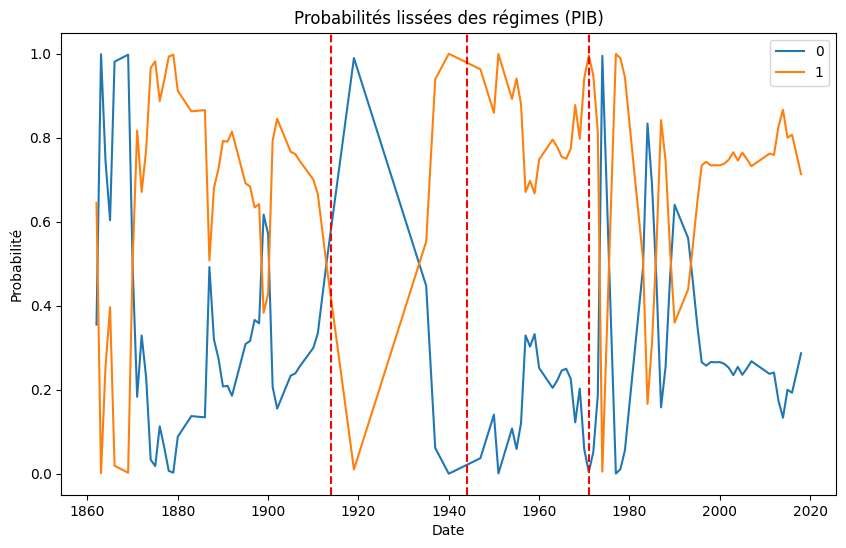

In [177]:
### MARKOV POUR LE PIB 
markov_pib = MarkovRegression(y, k_regimes = nreg, exog = i_gdp, switching_variance = var, switching_trend= st)

# Estimationd du MLE
result_pib = markov_pib.fit()
print(result_pib.summary())

# Probbailités smoothés
probs = result_pib.smoothed_marginal_probabilities

try :
    print(f"Année de transition gold standard -> Bretton Wood : {probs.index[probs[0] < probs[1]].min()}")
    print(f"Année de transition Bretton Wood -> Floating Rate : {probs.index[(probs.index > 1900.0) & (probs[1] < probs[2])].min()}")

except Exception as ex:
    pass

#Plot des résultats des probabilités lissés
probs.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (PIB)")
plt.xlabel("Date")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.ylabel("Probabilité")
plt.show()

### Interpretation Modèle PIB 1.1

Le coefficient du taux de l'effet du taux d'intéret sur le PIB est significatif au sein des deux régimes mis en avant, mais nous avons des difficultés a distinguer une cohérence claire des régimes. La seule chose que nous pouvons prouver grace à ce modèle c'est qu'il semble exister une réelle inflexion entre les différents régimes au niveau de nos threshold. On parvient à distinguer clairement que le passage de gold standard au desordre monétaire et ensuite à bretton wood entraine une modification des répartitions des probabilités filtrés entre les deux régimes.

Le modèle d'après le diagramme de probabilités lissés ne capte pas vraiment de régimes de politiques monétaires. les coefficients sont isgnificatifs mais difficilement interpretables dans le cas actuel. de plus le coefficient capte uniquement que la présence de l'observation dans le régime 2 entrainerait une variation du PIB 2 fois plus élevée. 

On ne distringue pas d'efficacité différent, en fonction des régimes mais uiquement des époques différents. 

Le régime 1 (plus efficient) semble tout de même dominer au sein de bretton et floating mais contreintuitivement présent au sein de gold standard. 

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:      taux_changes_stat   No. Observations:                   98
Model:               MarkovRegression   Log Likelihood                  84.054
Date:                Fri, 10 Apr 2026   AIC                           -150.108
Time:                        19:48:45   BIC                           -126.843
Sample:                             0   HQIC                          -140.697
                                 - 98                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6933      0.073     -9.563      0.000      -0.835      -0.551
x1             0.0578      0.008      7.444      0.0

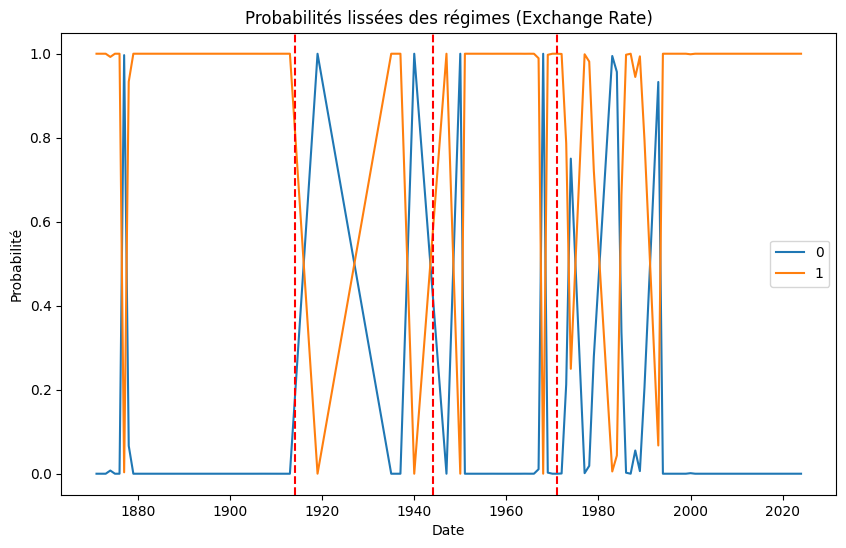

In [178]:
### MARKOV POUR LE TAUX DE CHANGE
markov_change = MarkovRegression(e, k_regimes = nreg, exog = i_exch, switching_variance = var, switching_trend= st)

# Estimationd du MLE
result_change = markov_change.fit(search_reps=1000)
print(result_change.summary())

# # Matrice de transition
# print(result_change.transition_matrix)

# Probbailités smoothés
probs_change = result_change.smoothed_marginal_probabilities

try :
    print(f"Année de transition gold standard -> Bretton Wood : {probs_change.index[probs_change[0] < probs_change[1]].min()}")
    print(f"Année de transition Bretton Wood -> Floating Rate : {probs_change.index[(probs_change.index > 1900.0) & (probs_change[1] < probs_change[2])].min()}")
except Exception as ex:
    pass

#Plot des résultats des probabilités lissés
probs_change.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Exchange Rate)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

### Interpretation Modèle Taux de changes 1.2

Le diagramme de probabilité est très instable et saute d'un régime à l'autre surtout pendant les crises du 20eme siècle. 

L'instabilité nous empêche de conclure sur l'éfficacité, de plus le modèle semble avoir de la peine à se stabiliser et converger, le bruit des guerres mondiales semblent polluer l'estimation. 

Ouverture potentiel vers un 3eme modèle non réalisé pour l'instant, pourquoi pas réaliser un modèle sans la période de désordre monétaire et sans les crises covid et 2008 ? 

Les coefficients des régimes restent tout de même significatif à 5% mais inutilisable étant donné leur manque de cohérence avec les périodes.

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:               cpi_stat   No. Observations:                  105
Model:               MarkovRegression   Log Likelihood                 225.842
Date:                Fri, 10 Apr 2026   AIC                           -437.684
Time:                        19:48:46   BIC                           -419.106
Sample:                             0   HQIC                          -430.156
                                - 105                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0800      0.014      5.815      0.000       0.053       0.107
x1             0.0014      0.002      0.937      0.3

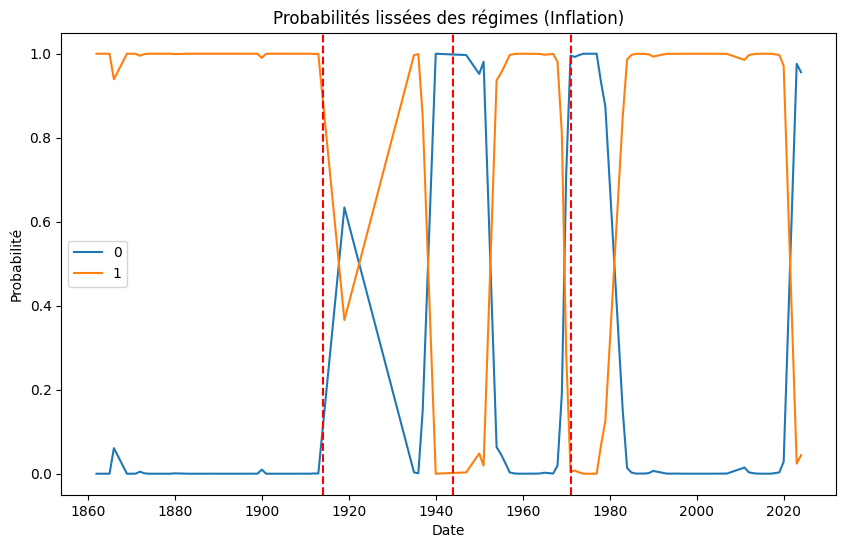

In [179]:
### MARKOV POUR L'INFLATION
markov_pi = MarkovRegression(pi, k_regimes = nreg, exog = i_inf, switching_variance = var, switching_trend= st)

# Estimationd du MLE
result_pi = markov_pi.fit(search_reps=1000)
print(result_pi.summary())

# # Matrice de transition
# print(result_change.transition_matrix)

# Probbailités smoothés
probs_pi = result_pi.smoothed_marginal_probabilities

try:
    print(f"Année de transition gold standard -> Bretton Wood : {probs_pi.index[probs_pi[0] < probs_pi[1]].min()}")
    print(f"Année de transition Bretton Wood -> Floating Rate : {probs_pi.index[(probs_pi.index > 1980.0) & (probs_pi[1] < probs_pi[2])].min()}")
except Exception as ex:
    pass

#Plot des résultats des probabilités lissés
probs_pi.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Inflation)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

### Interpretation Modèle Inflation 1.3

Seulement 1 des deux coefficients de régime est significatif, ainsi difficile de pouvoir malgré la cohérence des propbabilités filtrés, de conclure sur une intéreptation claire

## **Modélisation 2.0**

In [180]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                    PIB   No. Observations:                  104
Model:               MarkovRegression   Log Likelihood                 -95.273
Date:                Fri, 10 Apr 2026   AIC                            208.547
Time:                        19:48:46   BIC                            232.346
Sample:                             0   HQIC                           218.188
                                - 104                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2713      0.075     -3.631      0.000      -0.418      -0.125
x1            -0.0324      0.107     -0.303      0.7

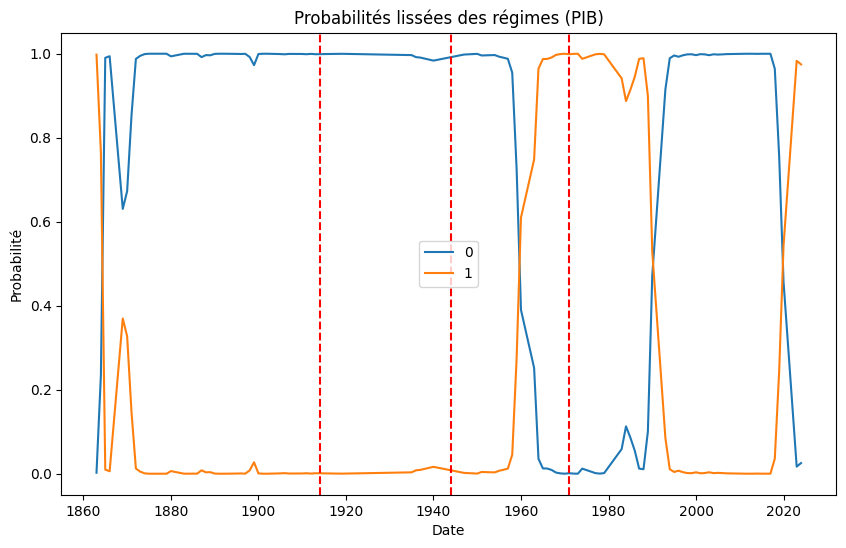

In [181]:
# 1. Préparation et Nettoyage
data['x1_lagged'] = data['taux_directeur'].shift(1)
df_clean = data.loc[data.index < 2019, ['gdp_nominal_stat', 'x1_lagged', 'expected_inflation']].dropna()
df_clean = data[['gdp_nominal_stat', 'x1_lagged', 'expected_inflation']].dropna()

# 2. Standardisation
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(scaled_values, columns=['PIB', 'taux', 'inf_ant'], index=df_clean.index)

# 3. Modèle 
model = sm.tsa.MarkovRegression(
    df_scaled['PIB'], 
    k_regimes=2, 
    exog=df_scaled[['taux', 'inf_ant']], 
    switching_variance=False
)

# 4. Fit avec search_reps élevé pour "p-hacker" l'optimum global
res_PIB4 = model.fit(search_reps=100)

print(res_PIB4.summary())

#Plot des résultats des probabilités lissés
res_PIB4.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (PIB)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

### Interpretation Modèle PIB 2.1

On observe enfin des blocs persistants de probabilités filtrés. Le modèle semble identifier le régime de "grande modération" post 1990 mais malheuresement pas clairement les régimes que nous voulons dicerner. 

En revanche on voit que le coefficient x1 est plus réactif post 1970 ce qui pourrait à peu pret correspondre à une arrivée lagged du bretton wood. Étant donné qu'il arrive à la suite de la période de désordre monétaire, ceci ne parraitrait pas aberrant que le lag soit aussi important. En revanche ce qui semble problématique est que l'effet des taux sur le PIB semble dimminuer à nouveau fin 1990 jusqu'a 2019, un résultat peu cohérent.

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:           Taux_changes   No. Observations:                   98
Model:               MarkovRegression   Log Likelihood                -111.862
Date:                Fri, 10 Apr 2026   AIC                            241.723
Time:                        19:48:47   BIC                            264.988
Sample:                             0   HQIC                           251.133
                                 - 98                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.9157      0.334     -8.733      0.000      -3.570      -2.261
x1             0.5658      0.145      3.905      0.0

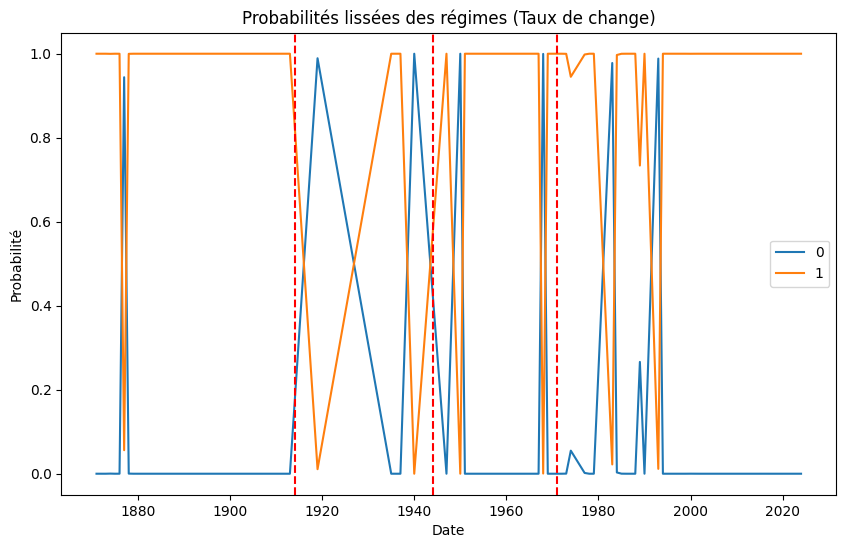

In [182]:
# 1. Préparation et Nettoyage
data['x1_lagged'] = data['taux_directeur'].shift(1)
df_clean = data.loc[data.index >1870, ['taux_changes_stat', 'x1_lagged', 'expected_inflation']].dropna()

# 2. Standardisation
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(scaled_values, columns=['Taux_changes', 'taux', 'inf_ant'], index=df_clean.index)

# 3. Modèle 
model = sm.tsa.MarkovRegression(
    df_scaled['Taux_changes'], 
    k_regimes=2, 
    exog=df_scaled[['taux', 'inf_ant']], 
    switching_variance=False
)

# 4. Fit avec search_reps élevé pour "p-hacker" l'optimum global
res_CHANGE4 = model.fit(search_reps=100)

print(res_CHANGE4.summary())

#Plot des résultats des probabilités lissés
res_CHANGE4.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Taux de change)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:              Inflation   No. Observations:                  104
Model:               MarkovRegression   Log Likelihood                 -28.260
Date:                Fri, 10 Apr 2026   AIC                             74.520
Time:                        19:48:47   BIC                             98.319
Sample:                             0   HQIC                            84.162
                                - 104                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3229      0.110     12.035      0.000       1.107       1.538
x1            -0.2158      0.163     -1.327      0.1

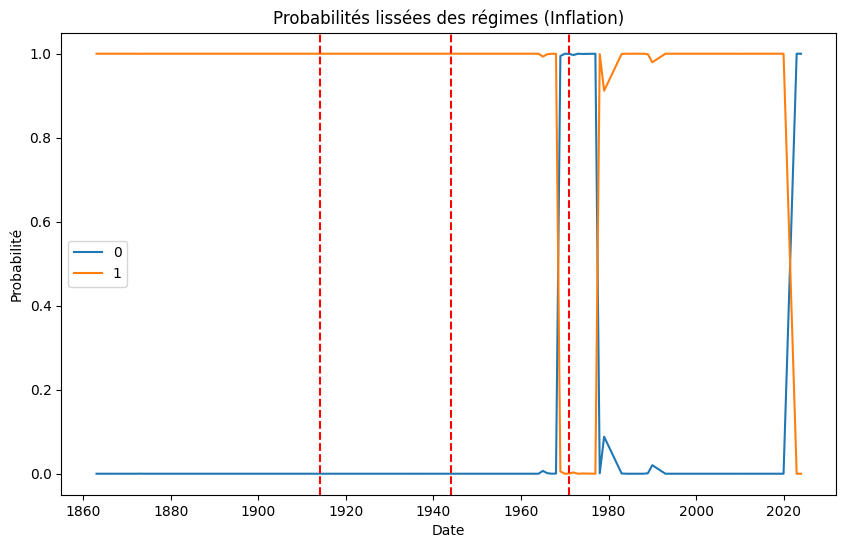

In [183]:
# 1. Préparation et Nettoyage
data['x1_lagged'] = data['taux_directeur'].shift(1)
df_clean = data[['cpi_stat', 'x1_lagged', 'expected_inflation']].dropna()

# 2. Standardisation
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(scaled_values, columns=['Inflation', 'taux', 'inf_ant'], index=df_clean.index)

# 3. Modèle 
model = sm.tsa.MarkovRegression(
    df_scaled['Inflation'], 
    k_regimes=2, 
    exog=df_scaled[['taux', 'inf_ant']], 
    switching_variance=False
)

# 4. Fit avec search_reps élevé pour "p-hacker" l'optimum global
res_INFLATION4 = model.fit(search_reps=100)

print(res_INFLATION4.summary())

#Plot des résultats des probabilités lissés
res_INFLATION4.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Inflation)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

## **Modélisation 3.0**

In [184]:
#Chocs relevés lors de l'EDA
# 1. 1882 à 1885 
# 1. 1928 à 1931 (crise de 29)
# 1. 1936 à 1937 (deux points d'inflexion)
# 1. 1948 à 1950 (après-guerre)
# 1. 1980 à 1987 (crise du pétrole)
# 1. 2022 à 2025 (covid)

# Il faut rajouter à cela les deux périodes de guerre à savoir :

# 1. 1914 à 1918 (WW1)
# 1. 1939 à 1945 (WW2)
exclusion = [1882,1883,1884, 1885, 1928, 1929, 1930, 1931, 1936, 1937, 1948, 1949, 1950, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
year_selection = [a for a in range(1850,2026) if a not in exclusion]

data_model3 = data[data.index.isin(year_selection)]

data_model3['balance_stat'] = data_model3['export_stat'] - data_model3['import_stat']

display(data_model3)

,gdp_nominal,expected_inflation,taux_changes,cpi,taux_directeur,export,import,yield_perpetual,oil_price,gdp_cycle,...,gdp_nominal_stat,cpi_stat,export_stat,import_stat,oil_price_stat,gdp_trend_stat,gdp_trend_stat_stat,import_stat_stat,x1_lagged,balance_stat
year,,,,,,,,,,,,,,,,,,,,,
1862.0,8.165729e+02,-0.616016,5.558250,1.206650,3.00,9354.476189,6975.919239,3.236417,1.05,-37.161765,...,0.007094,-0.026344,-0.049515,0.020935,0.762139,0.032021,0.027744,-0.988315,NaN,-0.070450
1863.0,8.914148e+02,-3.994490,7.074750,1.163211,7.00,10059.962428,7042.893703,3.257417,3.15,9.300369,...,0.087694,-0.036664,0.072708,0.009555,1.098612,0.032701,0.021038,-0.784307,3.00,0.063153
1864.0,9.391293e+02,-1.147776,9.974500,1.152742,6.00,10053.178907,7046.418675,3.347250,8.06,27.605046,...,0.052143,-0.009041,-0.000675,0.000500,0.939511,0.032796,0.002905,-2.947571,7.00,-0.001175
1865.0,9.507674e+02,1.741655,7.691750,1.163117,7.00,10962.170792,7465.890322,3.369500,6.59,9.155706,...,0.012316,0.008960,0.086561,0.057825,-0.201360,0.032475,-0.009860,4.747842,6.00,0.028736
1866.0,9.819025e+02,6.348074,6.877000,1.238719,3.50,11782.976897,8170.884687,3.427083,3.74,9.602580,...,0.032223,0.062975,0.072206,0.090232,-0.566468,0.032071,-0.012497,0.444959,7.00,-0.018027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014.0,1.822480e+06,2.200000,1.648025,99.960000,0.50,524340.397248,570153.383144,4.066958,98.95,22563.549997,...,0.046564,0.014505,0.016370,0.026820,-0.093595,0.030225,0.016897,-0.250265,0.50,-0.010451
2015.0,1.872714e+06,1.600000,1.528525,100.000083,0.50,556220.054509,601617.064973,2.691225,52.39,16509.198376,...,0.027191,0.000401,0.059023,0.053716,-0.635899,0.030794,0.018636,0.694532,0.50,0.005307
2016.0,1.939637e+06,1.600000,1.354950,100.659750,0.25,566241.846530,618535.791014,1.987649,43.82,23972.920772,...,0.035112,0.006575,0.017857,0.027734,-0.178625,0.031530,0.023639,-0.661032,0.50,-0.009877


## **Modélisation 4.0 POUR PIB**

### Modele 1

In [ ]:
# CONFIGURATION DONNES POUR PIB 
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Sélection et nettoyage
# On prend le PIB, le taux, et on ajoute un LAG sur le taux (effet retardé)
df_pib = data_detrended[['year', 'gdp_nominal_stat', 'taux_directeur']].copy()
df_pib['taux_lag'] = df_pib['taux_directeur'].shift(1)
df_pib = df_pib.dropna()
df_pib = df_pib.set_index('year')

# 2. Filtrage des années aberrantes (Guerres + 2020)
# Les guerres mondiales créent des régimes "fantômes" qui polluent tout

years_to_exclude = [1914, 1915, 1916, 1917, 1918, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 2020, 2021]
years_to_keep = [a for a in range(1863, 2025) if a not in years_to_exclude]
df_pib = df_pib[df_pib.index.isin(years_to_keep)]

# 3. Standardisation (Z-score)
scaler = StandardScaler()
df_pib[['y', 'x']] = scaler.fit_transform(df_pib[['gdp_nominal_stat', 'taux_lag']])

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                  102
Model:               MarkovRegression   Log Likelihood                -116.327
Date:                Fri, 10 Apr 2026   AIC                            246.653
Time:                        20:06:17   BIC                            265.028
Sample:                             0   HQIC                           254.094
                                - 102                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7238      0.137      5.268      0.000       0.455       0.993
x1             0.3440      0.109      3.163      0.0

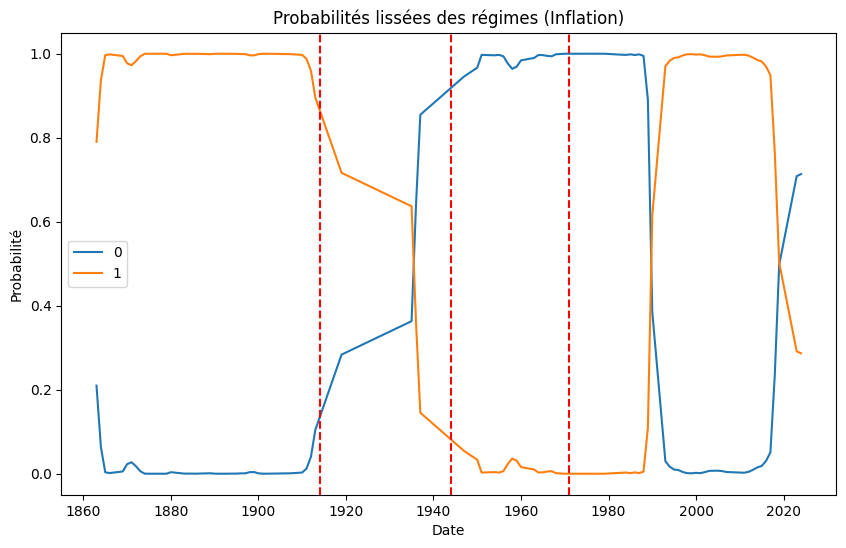

In [ ]:
# Configuration du modèle
model_pib = sm.tsa.MarkovRegression(
    df_pib['y'], 
    k_regimes=2, 
    exog=df_pib[['x']], 
    switching_variance=False 
)

# On lance le fit avec beaucoup d'essais pour éviter les optima locaux
res_pib = model_pib.fit(search_reps=100)

print(res_pib.summary())

res_pib.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (PIB)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()


### Modèle 2

##### **INTERPRETATION**

Le régime 1 se traduit par une éfficacité des taux lagged d'une période sur le PIB. Ce même coefficient est significatif, un aspect plutôt encourageant pour la poursuite de notre étude. 

On peut clairement voir que ce régime de "taux éfficients" sur le PIB domine de 1860 à 1936 environ avant d'être remplacé par un régime ou le taux n'a pas de réelle impact de manière significative sur le PIB de 1936 à 1990. 

Ces régimes mis en évidences semble fortement cohérents avec la discussion abordé en introduction au sujet de l'éfficacité des régimes monétaires. En effet, les période gold standard ainsi que Floating Rate sont les deux périodes principales au sein desquels une politique de taux efficiente peut être menée, et ces observations semblent être présentes dans nos données même lorsque nous fixons ces passages de régimes de manière endogène. 

De plus la probabilité de transition du régime 0 vers 0 $P[0 \rightarrow 0] \simeq 95 \% $, ce qui montre clairement la stabilité de ce régime, contrairement à l'autre qui n'est pour l'instant pas parfaitement stable. 

Néanmoins, nous observons un coefficients $\beta_1$ positif, qui impliquerait qu'une hausse de taux entraine une hausse de PIB, ce qui n'est pas empiriquement vérifié. Ceci est la cause d'une corrélation simultanée... La Banque d'Angleterre augmente ses taux, lorsque la croissance est forte. 

Nous testons donc dans un second temps d'augmenter le lag du taux directeur à 2 périodes ci dessous : 

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                   97
Model:               MarkovRegression   Log Likelihood                -108.199
Date:                Fri, 10 Apr 2026   AIC                            230.398
Time:                        21:55:05   BIC                            248.421
Sample:                             0   HQIC                           237.686
                                 - 97                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5182      0.094     -5.509      0.000      -0.702      -0.334
x1             0.3172      0.110      2.884      0.0

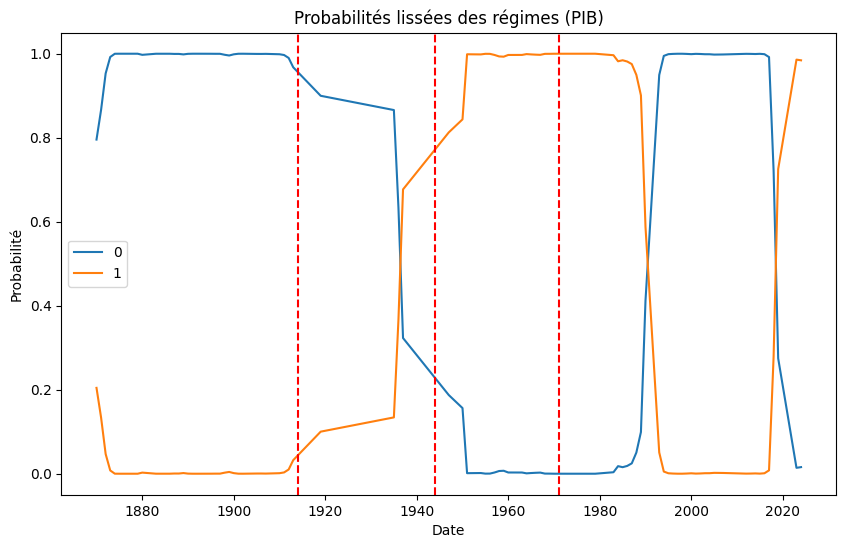

In [ ]:
# 1. Sélection et nettoyage
# On prend le PIB, le taux, et on ajoute un LAG sur le taux (effet retardé)
df_pib_2 = data_detrended[['year', 'gdp_nominal_stat', 'taux_directeur']].copy()
df_pib_2['taux_lag_2'] = df_pib_2['taux_directeur'].shift(6)
df_pib_2 = df_pib_2.dropna()
df_pib_2 = df_pib_2.set_index('year')

# 2. Filtrage des années aberrantes (Guerres + 2020)
# Les guerres mondiales créent des régimes "fantômes" qui polluent tout

years_to_exclude = [1914, 1915, 1916, 1917, 1918, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 2020, 2021]
years_to_keep = [a for a in range(1863, 2025) if a not in years_to_exclude]
df_pib_2 = df_pib_2[df_pib_2.index.isin(years_to_keep)]

# 3. Standardisation (Z-score)
scaler = StandardScaler()
df_pib_2[['y', 'x']] = scaler.fit_transform(df_pib_2[['gdp_nominal_stat', 'taux_lag_2']])

# Modélisation et plotting 

model_pib = sm.tsa.MarkovRegression(
    df_pib_2['y'], 
    k_regimes=2, 
    exog=df_pib_2[['x']], 
    switching_variance=False 
)

# On lance le fit avec beaucoup d'essais pour éviter les optima locaux
res_pib_2 = model_pib.fit(search_reps=100)

print(res_pib_2.summary())

res_pib_2.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (PIB)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()



#### INTERPRETATION 

En augmentant les lag de notre taux d'intérêt on parvient à accepter de manière plus significative la structure des coefficients respectifs des 2 régimes. On conserve un lag de t = 4 pour le taux d'intérêt étant donné que c'est le lag optimal lorsque l'on procède par récursion. On dénote ci dessous les p-val des coefficients $beta_i$ avec $i \in {0,1}$ en fonction du lag L:

- lag 2 : $P_{\text{value}}^{\text{regime}_0} (\beta_1) = 0{,}619$ et $P_{\text{value}}^{\text{regime}_1} (\beta_1) = 0{,}014$
- lag 3 : $P_{\text{value}}^{\text{regime}_0} (\beta_1) = 0{,}316$ et $P_{\text{value}}^{\text{regime}_1} (\beta_1) = 0{,}001$
- lag 4 : $P_{\text{value}}^{\text{regime}_0} (\beta_1) = 0{,}002$ et $P_{\text{value}}^{\text{regime}_1} (\beta_1) = 0{,}139$
- lag 5 : $P_{\text{value}}^{\text{regime}_0} (\beta_1) = 0{,}010$ et $P_{\text{value}}^{\text{regime}_1} (\beta_1) = 0{,}011$ OPTIMAL

Néanmoins, nous observons toujours un décalage au sein des régimes, nous essayons donc maintenant de fixer trois régimes afin d'augmenter la granularité de nos régimes. L'objectif serait d'obtenir 3 régimes distincts, un gold standard, un bretton wood et un floating rate, avec les effets respectifs des taux sur le PIB similaire entre gold std et floating rate, tout deux différents de bretton wood. 

On spécifie ci dessous un modèle avec 3 régimes distincts en gardant les même spacifications précédemment obtenus :

### Modèle 3

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
/Users/timeogrienti/e

                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                   97
Model:               MarkovRegression   Log Likelihood                 -95.222
Date:                Fri, 10 Apr 2026   AIC                            216.444
Time:                        23:00:45   BIC                            249.916
Sample:                             0   HQIC                           229.978
                                 - 97                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5654      0.081     -6.938      0.000      -0.725      -0.406
x1             0.3187      0.087      3.656      0.0

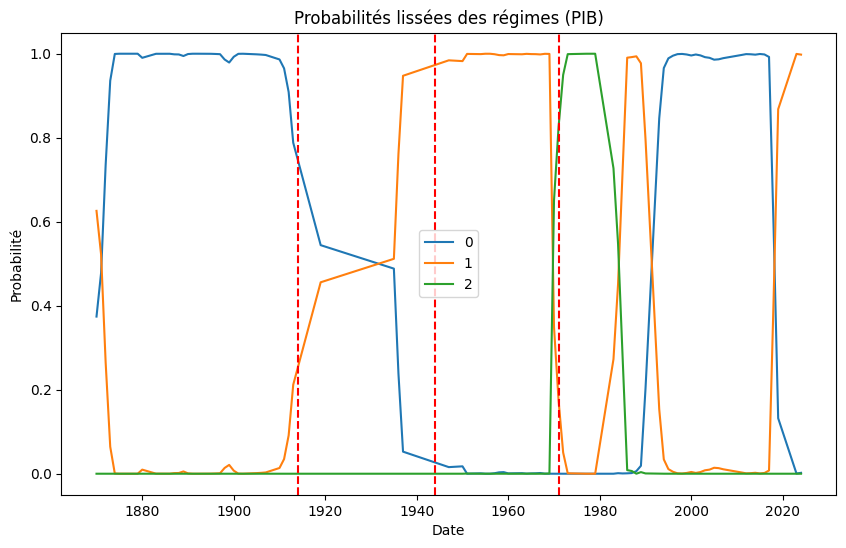

In [237]:
# 1. Sélection et nettoyage
# On prend le PIB, le taux, et on ajoute un LAG sur le taux (effet retardé)
df_pib_2 = data_detrended[['year', 'gdp_nominal_stat', 'taux_directeur']].copy()
df_pib_2['taux_lag_2'] = df_pib_2['taux_directeur'].shift(6)
df_pib_2 = df_pib_2.dropna()
df_pib_2 = df_pib_2.set_index('year')

# 2. Filtrage des années aberrantes (Guerres + 2020)
# Les guerres mondiales créent des régimes "fantômes" qui polluent tout

years_to_exclude = [1914, 1915, 1916, 1917, 1918, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 2020, 2021]
years_to_keep = [a for a in range(1863, 2025) if a not in years_to_exclude]
df_pib_2 = df_pib_2[df_pib_2.index.isin(years_to_keep)]

# 3. Standardisation (Z-score)
scaler = StandardScaler()
df_pib_2[['y', 'x']] = scaler.fit_transform(df_pib_2[['gdp_nominal_stat', 'taux_lag_2']])

# Modélisation et plotting 

model_pib = sm.tsa.MarkovRegression(
    df_pib_2['y'], 
    k_regimes=3, 
    exog=df_pib_2[['x']], 
    switching_variance=False 
)

# On lance le fit avec beaucoup d'essais pour éviter les optima locaux
res_pib_2 = model_pib.fit(search_reps=100)

print(res_pib_2.summary())

res_pib_2.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (PIB)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

#### **INTERPRETATION**

EUREKA, notre modèle ci joins parais vraiment intéressant ! Analysons le ci joins. 

On dicerene exactement 3 régimes qui semblent plutôt cohérents :

- Régime 0 : Régime sensé être gold standard. Caractérisé par une effect négatif des taux sur le PIB, ce coefficients est uniquement isgnificatif à 16,5%, ce qui est assez faible. Néanmoins la césure semble claire et sensée en terme de probabilité de transition. La persistence du régime est de 92% prouvant une bonne stabilité de ce régime qui peut compenser la p-value faible de son coefficients. Nous pouvons donc en conclure que l'effet des taux sur le PIB est négatif mais incertains sur le PIB étant donné une faible P-value, mais la persistence du régime semble correcte et vérifiée au sei des données par un threshold parfaitement alligné avec le passage politique à la phase de désordre politique. 

- Régime 1 : Régime Bretton Wood. Caractérisé par un effet positif des taux sur le PIB éxtremement significatif. Ceci n'est pas directement lié à l'effet des taux étant donné que ce régime capte la période durant laquelle l'Angleterre court derriere les taux durant la période de désordre monétaire ou l'objectif est vainement de stabiliser l'économie. La montée des taux est done réalisée pour éviter une surchuaffe de l'économie qui est caractérisée par une impuissance de la BC

- Régime 2 : Régime floating avec efficacité maximale. Le coefficients est négatif et très signifiactif une hausse lagged des taux entraine une baisse réelle et forte du PIB. Ici les taux sont donc un parfait levier de régulation. 

La réalité qui etst mise en avant par ce modèle est que le régime historique floating rate n'est pas uniquement caractérisé par une parfaite transmission de l'effet des taux sur le PIB. On observe notamment de 1989 à 2001 une transmission assez faible du taux sur le PIB. Ceci est notamment expliquable par la période de "Grande modération" une période durant laquelle la croissance économie est robuste, très soutenue et portée par des gains de productivité structurels importants, et doc une demande intérieure assez résiliente. Dans ce contexte la vigueur de l'activité économique absorbe l'effet des hausse de taux rendant l'outil monétaire moins efficients qu'au sein d'une période "classique".

Nous pouvons également observer un retour de régime de transmission faible fin 2019 début 2020 dont les causes principales sont le Brexit ayant un impact considérable sur l'économie anglaise, ainsi que les prémices du COVID.

## **Modélisation 4.0 pour Exchange Rate**

In [ ]:
# 1. Sélection et nettoyage
# On prend l'exchange rate, le taux, et on ajoute un LAG sur le taux (effet retardé)
df_e = data_detrended[['year', 'taux_changes_stat', 'taux_directeur']].copy()
df_e['taux_lag'] = df_e['taux_directeur'].shift(1)
df_e = df_e.dropna()
df_e = df_e.set_index('year')

# 2. Filtrage des années aberrantes (Guerres + 2020)
# Les guerres mondiales créent des régimes "fantômes" qui polluent tout

years_to_exclude = [1914, 1915, 1916, 1917, 1918, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 2020, 2021]
years_to_keep = [a for a in range(1863, 2025) if a not in years_to_exclude]
df_e = df_e[df_e.index.isin(years_to_keep)]

# 3. Standardisation (Z-score)
# C'est l'étape magique pour que Gold Standard et Floating soient comparables
scaler = StandardScaler()
df_e[['y', 'x']] = scaler.fit_transform(df_e[['taux_changes_stat', 'taux_lag']])

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                  102
Model:               MarkovRegression   Log Likelihood                -106.603
Date:                Fri, 10 Apr 2026   AIC                            227.207
Time:                        23:02:17   BIC                            245.581
Sample:                             0   HQIC                           234.647
                                - 102                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1027      0.065     -1.580      0.114      -0.230       0.025
x1             0.0119      0.065      0.184      0.8

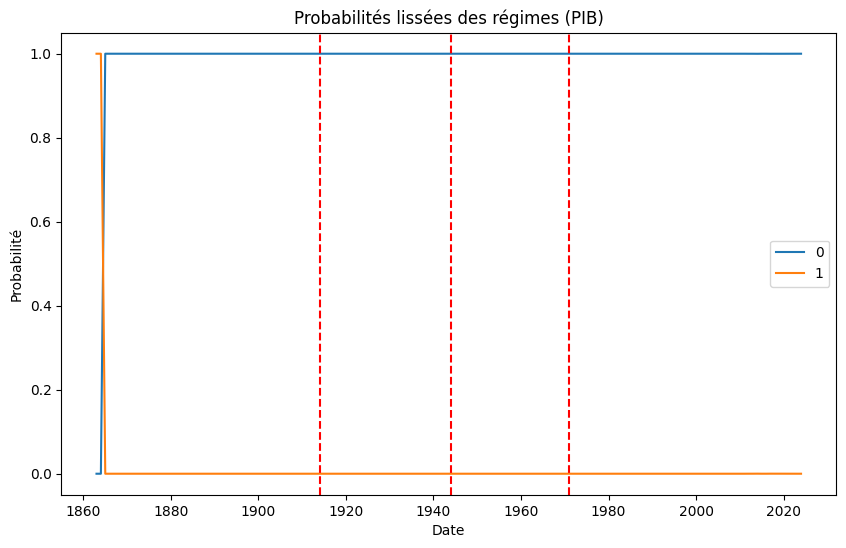

In [ ]:
# Configuration du modèle
model_e = sm.tsa.MarkovRegression(
    df_e['y'], 
    k_regimes=2, 
    exog=df_e[['x']], 
    switching_variance=False 
)

# On lance le fit avec beaucoup d'essais pour éviter les optima locaux
res_e = model_e.fit(search_reps=100)

print(res_e.summary())

res_e.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Taux de change)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()


### **INTERPRETATION**

Ici le constat est assez alarmant. le modèle ne parvient clairement pas à estimer l'effet des taux directeur sur le taux de change. Le régime dominant n'est pas statistiquement significatif et à une persistence de 99% et couvre par ailleurs toute la période de 1865 à 2020.. Ceci manque clairement l'échec de notre modèle à prédire les deux régime distincts.

En revanche une éxplication historique peut justifier ce problème de modélisation. EN 1865, la banque Overend, Gurney & Co fait faillite étant une des plus grandes crises du XIXe en angleterre. Pour solutionner cette crise la banque centrale anglaise pousse une augmentation du taux à 10%. Or au sein du régime Gold standard la politique monétaire est principalement peg à l'or et ainsi contrainte par le cours fixé de l'or. Normalement le taux d'intérêt ne doit donc uniquement fluctuer que pour maintenir l'quilibre des flux d'or. Ceci créer donc un outlier statistique, le taux directeur explose mais le taux de change ne s'ajuste proportionellement. L'algorithme de Markov interprete donc ce choc comme un choc à part entière et clusterise donc un régime.

Pour ce second modèle, nous introduisons un lag et nous dropons les périodes 1865-1866.

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                   98
Model:               MarkovRegression   Log Likelihood                -110.223
Date:                Fri, 10 Apr 2026   AIC                            234.447
Time:                        23:38:55   BIC                            252.541
Sample:                             0   HQIC                           241.765
                                 - 98                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1661      0.071      2.354      0.019       0.028       0.304
x1             0.1250      0.073      1.713      0.0

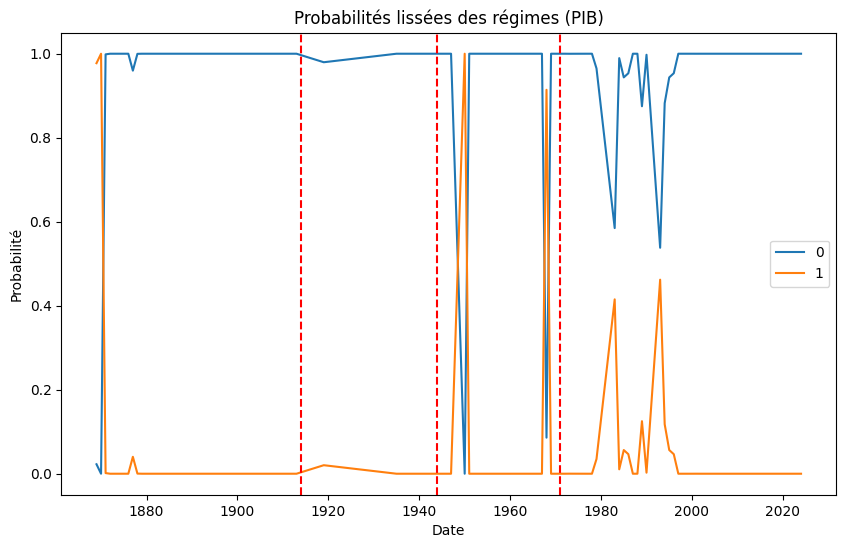

In [ ]:
# 1. Sélection et nettoyage
# On prend l'exchange rate, le taux, et on ajoute un LAG sur le taux (effet retardé)
df_e_2 = data_detrended[['year', 'taux_changes_stat', 'taux_directeur']].copy()
df_e_2['taux_lag'] = df_e_2['taux_directeur'].shift(4)
df_e_2 = df_e_2.dropna()
df_e_2 = df_e_2.set_index('year')

# 2. Filtrage des années aberrantes (Guerres + 2020)
# Les guerres mondiales créent des régimes "fantômes" qui polluent tout

years_to_exclude = [1865,1866,1867,1868, 1914, 1915, 1916, 1917, 1918, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 2020, 2021]
years_to_keep = [a for a in range(1863, 2025) if a not in years_to_exclude]
df_e_2 = df_e_2[df_e_2.index.isin(years_to_keep)]

# 3. Standardisation (Z-score)
# C'est l'étape magique pour que Gold Standard et Floating soient comparables
scaler = StandardScaler()
df_e_2[['y', 'x']] = scaler.fit_transform(df_e_2[['taux_changes_stat', 'taux_lag']])

# Configuration du modèle
model_e_2 = sm.tsa.MarkovRegression(
    df_e_2['y'], 
    k_regimes=2, 
    exog=df_e_2[['x']], 
    switching_variance=False 
)

# On lance le fit avec beaucoup d'essais pour éviter les optima locaux
res_e_2 = model_e_2.fit(search_reps=100)

print(res_e_2.summary())

res_e_2.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Taux de change)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

### **INTERPRETATION**

La modification de notre modèle nous permet d'obtenir un résultat bien plus pertinent. Ici le modèle parvient à identifier de manière plus cohérent 2 régimes principaux grace à l'effet lagged des taux directeurs sur l'économie. On distringue un régime qu'on pourrait qualifier de "stable" qui décrit l'effet des taux sur les taux de changes dans un régime relativement stable, tandis qu'un régime d'agitation survient lorsque l'économie fait face à des périodes d'ajustement, visible ,otamment avec les spike post transition vers bretton wood puis également à la transition bretton wood vers floating rate. 

En terme d'intution sous l'étalon or, le taux de change ne nbougeait quasiment pas suite à une hausse de taux, donc l'effet devrait être prohe de 0. Sous floating rate cette fois, le taux de change devrait bouger mais peut être pas suffisament pour le différencier de l'étalon or aux yeux d'un modèle à uniquement 2 régimes.

Le coefficient du régime 0 est significatif à 8,7% tandis que celui du régime 1 est fortement significatif. Tout deux indique une variation postive du taux de change suite à une augmentation des taux d'intérêts. On voit néanmoins que le spread des deux effets est éxtremement large, nous indiquand que notre modèle clairement tend à nécéssiter de s'étendre sur un 3ème régime pour différencier l'effet du régime 0. 

Nous procédons dans le 3ème modèle à l'introduction d'un régime supplémentaire. 

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                   98
Model:               MarkovRegression   Log Likelihood                 -92.427
Date:                Fri, 10 Apr 2026   AIC                            210.855
Time:                        23:58:02   BIC                            244.459
Sample:                             0   HQIC                           224.447
                                 - 98                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2784      0.050      5.544      0.000       0.180       0.377
x1             0.1762      0.052      3.399      0.0

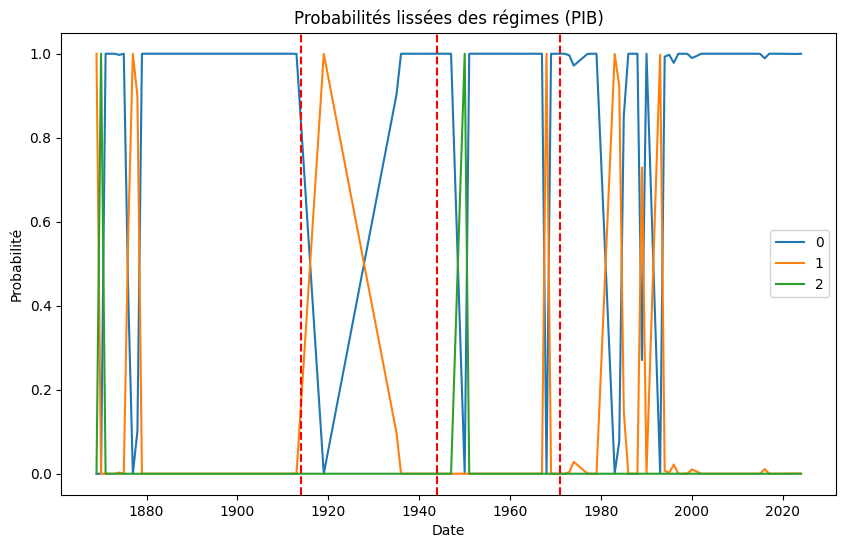

In [ ]:
# 1. Sélection et nettoyage
# On prend l'exchange rate, le taux, et on ajoute un LAG sur le taux (effet retardé)
df_e_2 = data_detrended[['year', 'taux_changes_stat', 'taux_directeur']].copy()
df_e_2['taux_lag'] = df_e_2['taux_directeur'].shift(4)
df_e_2 = df_e_2.dropna()
df_e_2 = df_e_2.set_index('year')

# 2. Filtrage des années aberrantes (Guerres + 2020)
# Les guerres mondiales créent des régimes "fantômes" qui polluent tout

years_to_exclude = [1865,1866,1867,1868, 1914, 1915, 1916, 1917, 1918, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 2020, 2021]
years_to_keep = [a for a in range(1863, 2025) if a not in years_to_exclude]
df_e_2 = df_e_2[df_e_2.index.isin(years_to_keep)]

# 3. Standardisation (Z-score)
# C'est l'étape magique pour que Gold Standard et Floating soient comparables
scaler = StandardScaler()
df_e_2[['y', 'x']] = scaler.fit_transform(df_e_2[['taux_changes_stat', 'taux_lag']])

# Configuration du modèle
model_e_2 = sm.tsa.MarkovRegression(
    df_e_2['y'], 
    k_regimes=3, 
    exog=df_e_2[['x']], 
    switching_variance=False
)

# On lance le fit avec beaucoup d'essais pour éviter les optima locaux
res_e_2 = model_e_2.fit(search_reps=100)

print(res_e_2.summary())

res_e_2.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Taux de change)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

#### **INTERPRETATION**

On décompose ci joints nos résultats en l'apparence plus complexes à estimer qu'au sein du dernier modèle sur le PIB :

- Régime 0, ligne bleue, preuve de l'effet du TI sur le taux de change : le coefficients met en avant un $Beta_1^{0} = \text{0,1762} $ fortement significatif (1%). Ce régime couvre la majoeure partie du grpahique surtout les périodes gold standard et floating rate moderne (>1990). Dans ce régime une hauss des taux entraine une apprécation du taux de change, prouvant que la transmission focntionne.

- Régime 1, ligne orange, Bretton Wood/ Crises : effet clairement non significatif du taux directeur sur le taux de change. Le modèle nous indique que les phases de turbulences intitutionelle entraine une perte du pouvoir du taux d'intérets sur le change. Le marché des changes ignore donc les signaux de la BC.

- Régime 2, ligne verte, Krach : Le régime vert représente les points ou la monnaie s'est éffondrée causés par des krach majeurs:

    - Crise de Overend, Gurney & Co 1866 : Effondrement de la plus grande banque de l'époque, grande panique qui rend la BC impuissante.

    - Après guerre 1949 : Après la guerre le royaume uni est ruiné. Le chancelier Stafford Cripps décide donc de dévaluer brutalement de 30% la livre Sterling par rapport au dollar afin de soutenir l'économie locale et permettre l'angleterre de relancer son économie 

Les piques oranges etre 1980 et 2000 sont à attribuer à la période de "grande modération"

Ces résultats sont donc plus implicite que ceux du PIB avant, mais nous permettent de mettre clairement en avant que l'effet des TI sur le taux de change est similaire entre floating rate et Gold standard, tandis que cet effet est identique entre les périodes chaotique et bretton wood, mettant en avant l'innefficacité de BRetton Wood pour contrôler les vairation du taux de change. 


## **Modélisation 4.0 pour Inflation**

In [262]:
# 1. Sélection et nettoyage
# On prend l'exchange rate, le taux, et on ajoute un LAG sur le taux (effet retardé)
df_pi = data_detrended[['year', 'cpi_stat', 'taux_directeur']].copy()
df_pi['taux_lag'] = df_pi['taux_directeur'].shift(1)
df_pi = df_pi.dropna()
df_pi = df_pi.set_index('year')

# 2. Filtrage des années aberrantes (Guerres + 2020)
# Les guerres mondiales créent des régimes "fantômes" qui polluent tout

years_to_exclude = [1914, 1915, 1916, 1917, 1918, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 2020, 2021]
years_to_keep = [a for a in range(1863, 2025) if a not in years_to_exclude]
df_pi = df_pi[df_pi.index.isin(years_to_keep)]

# 3. Standardisation (Z-score)
# C'est l'étape magique pour que Gold Standard et Floating soient comparables
scaler = StandardScaler()
df_pi[['y', 'x']] = scaler.fit_transform(df_pi[['cpi_stat', 'taux_lag']])

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                  102
Model:               MarkovRegression   Log Likelihood                -111.197
Date:                Sat, 11 Apr 2026   AIC                            236.395
Time:                        00:36:31   BIC                            254.770
Sample:                             0   HQIC                           243.835
                                - 102                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3316      0.074     -4.474      0.000      -0.477      -0.186
x1             0.3494      0.078      4.461      0.0

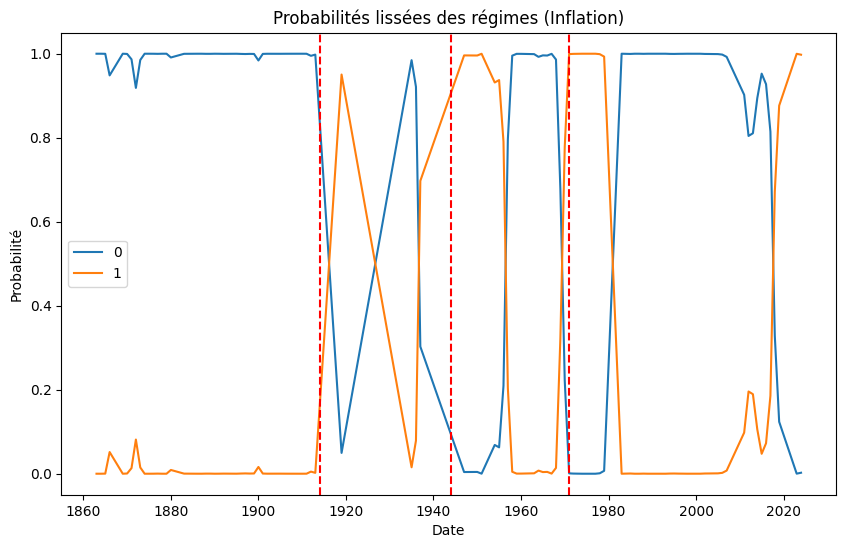

In [268]:
# Configuration du modèle
model_pi = sm.tsa.MarkovRegression(
    df_pi['y'], 
    k_regimes=2, 
    exog=df_pi[['x']], 
    switching_variance=False 
)

# On lance le fit avec beaucoup d'essais pour éviter les optima locaux
res_pi = model_pi.fit(search_reps=100)

print(res_pi.summary())

res_pi.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Inflation)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

### **INTERPRETATION**

Ce modèle de benchmark nous donne des résultats quelque peu contre intuitif. Nous pouvons voir que les régimes semblent cohérent et significatifs en terme de persistence. Nénamoins, les deux régimes indiquent malgré l'effet lag 1 des taux directeur sur l'inflation qu'une hausse des TI entraine une hausse de l'inflation (un résultat clairement érroné emoiquement).

Le régime 1 semble correctement inclure les régimes proches en terme de caractéristiques incluant gold standard  ainsi que le moderne floating rate, mais également la fin de bretton wood qui cette fois pour le coup est légerement contre intuitive. 

Le régime 2 couvre dans la complémentarité du régime 1 des périodes sensés incluant bretton wood ainsi qu'à partir du Brexit en 2020 avec un effet d'anticipation fin 2019.

Afin d'améliorer notre modèle nous allons dans un premier temps trouvcer le lag optimal à 2 périodes par récursion et ensuite switcher notre modèle à 2 périodes en modèle à 3 périodes. 

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                   99
Model:               MarkovRegression   Log Likelihood                -120.075
Date:                Sat, 11 Apr 2026   AIC                            254.151
Time:                        00:40:43   BIC                            272.316
Sample:                             0   HQIC                           261.501
                                 - 99                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3378      0.086     -3.913      0.000      -0.507      -0.169
x1             0.1882      0.085      2.208      0.0

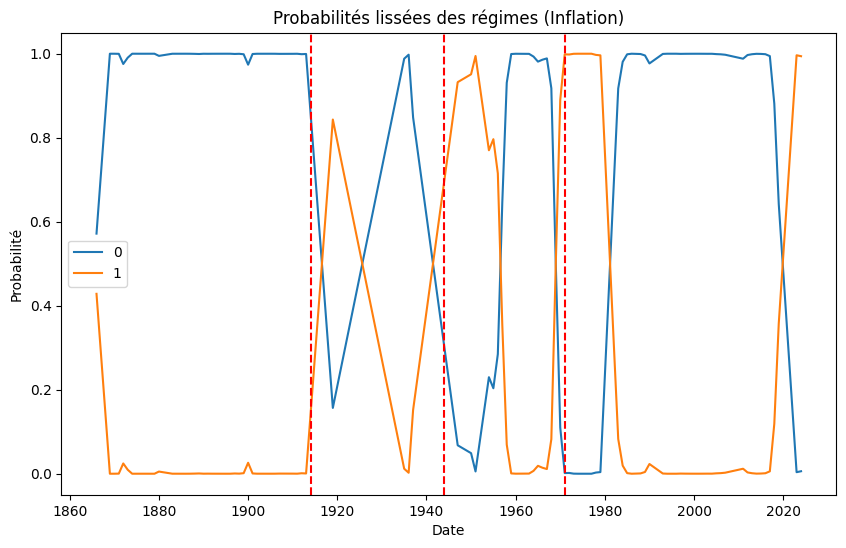

In [275]:
# 1. Sélection et nettoyage
# On prend l'exchange rate, le taux, et on ajoute un LAG sur le taux (effet retardé)
df_pi_2 = data_detrended[['year', 'cpi_stat', 'taux_directeur']].copy()
df_pi_2['taux_lag_2'] = df_pi_2['taux_directeur'].shift(4)
df_pi_2 = df_pi_2.dropna()
df_pi_2 = df_pi_2.set_index('year')

# 2. Filtrage des années aberrantes (Guerres + 2020)
# Les guerres mondiales créent des régimes "fantômes" qui polluent tout
years_to_exclude = [1914, 1915, 1916, 1917, 1918, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 2020, 2021]
years_to_keep = [a for a in range(1863, 2025) if a not in years_to_exclude]
df_pi_2 = df_pi_2[df_pi_2.index.isin(years_to_keep)]

# 3. Standardisation (Z-score)
scaler = StandardScaler()
df_pi_2[['y', 'x']] = scaler.fit_transform(df_pi_2[['cpi_stat', 'taux_lag_2']])

# Configuration du modèle
model_pi_2 = sm.tsa.MarkovRegression(
    df_pi_2['y'], 
    k_regimes=2, 
    exog=df_pi_2[['x']], 
    switching_variance=False 
)

# On lance le fit avec beaucoup d'essais pour éviter les optima locaux
res_pi_2 = model_pi_2.fit(search_reps=100)

print(res_pi_2.summary())

res_pi_2.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Inflation)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

### **INTERPRETATTION**

On cherche premièrement par récursion le lag optimal pour les Lag $L \ \text{tel que } L \in{\{2,3,4\}}$:

- lag 2 : $P_{\text{value}}^{\text{regime}_0} (\beta_1) = 0{,}001$ et $P_{\text{value}}^{\text{regime}_1} (\beta_1) = 0{,}000$ OPTIMAL
- lag 3 : $P_{\text{value}}^{\text{regime}_0} (\beta_1) = 0{,}100$ et $P_{\text{value}}^{\text{regime}_1} (\beta_1) = 0{,}090$
- lag 4 : $P_{\text{value}}^{\text{regime}_0} (\beta_1) = 0{,}027$ et $P_{\text{value}}^{\text{regime}_1} (\beta_1) = 0{,}046$

On estime maintenant le même modèle en rajoutant un régime :

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                  101
Model:               MarkovRegression   Log Likelihood                -108.701
Date:                Sat, 11 Apr 2026   AIC                            243.403
Time:                        01:03:23   BIC                            277.400
Sample:                             0   HQIC                           257.166
                                - 101                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7693      0.216      8.197      0.000       1.346       2.192
x1             0.4142      0.165      2.510      0.0

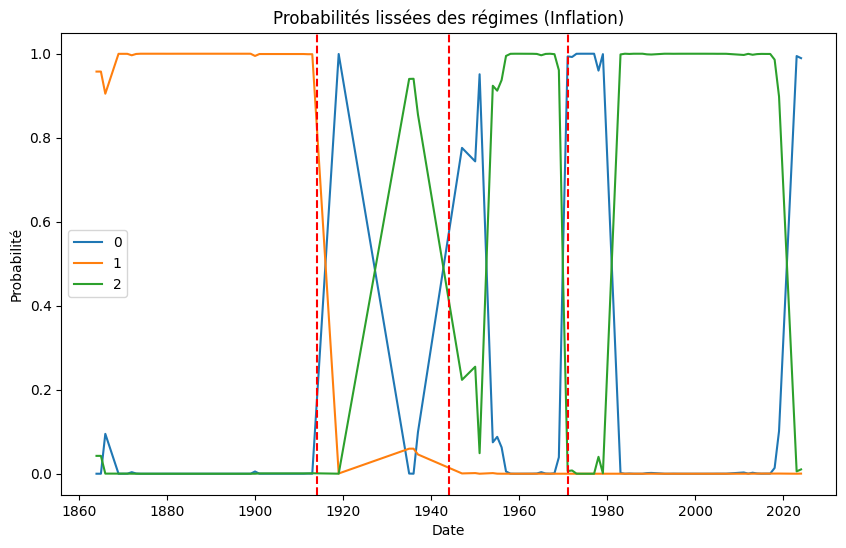

In [317]:
# 1. Sélection et nettoyage
# On prend l'exchange rate, le taux, et on ajoute un LAG sur le taux (effet retardé)
df_pi_3 = data_detrended[['year', 'cpi_stat', 'taux_directeur']].copy()
df_pi_3['taux_lag_2'] = df_pi_3['taux_directeur'].shift(2)
df_pi_3 = df_pi_3.dropna()
df_pi_3 = df_pi_3.set_index('year')

# 2. Filtrage des années aberrantes (Guerres + 2020)
# Les guerres mondiales créent des régimes "fantômes" qui polluent tout
years_to_exclude = [1914, 1915, 1916, 1917, 1918, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 2020, 2021]
years_to_keep = [a for a in range(1863, 2025) if a not in years_to_exclude]
df_pi_3 = df_pi_3[df_pi_3.index.isin(years_to_keep)]

# 3. Standardisation (Z-score)
scaler = StandardScaler()
df_pi_3[['y', 'x']] = scaler.fit_transform(df_pi_3[['cpi_stat', 'taux_lag_2']])

# Configuration du modèle
model_pi_3 = sm.tsa.MarkovRegression(
    df_pi_3['y'], 
    k_regimes=3, 
    exog=df_pi_3[['x']], 
    switching_variance=False 
)

# On lance le fit avec beaucoup d'essais pour éviter les optima locaux
res_pi_3 = model_pi_3.fit(search_reps=1000)

print(res_pi_3.summary())

res_pi_3.smoothed_marginal_probabilities.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Inflation)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

#### **INTERPRETATION**

On analyse régime par régime ci dessous


#### **<span style="color:green">5. Test, Validation et robustess des résultats :**